In [ ]:
import re
import os
import glob
import json
import anndata as ad
import pandas as pd
import numpy as np
import seaborn as sns
import scipy as sp
import scanpy as sc
import matplotlib as mpl
import matplotlib.pyplot as plt
from adjustText import adjust_text

In [ ]:
# plot appearance default parameters

mpl.rc('lines', linewidth=0.4)
mpl.rc('font', family="Helvetica", size=8, )
mpl.rc('axes', labelsize=8, titlesize=8, linewidth=0.4)
mpl.rc('legend', fontsize=8)
mpl.rc('xtick', labelsize=6)
mpl.rc('xtick.major', width=0.4, size=2)
mpl.rc('xtick.minor', width=0.4, size=1)
mpl.rc('ytick', labelsize=6)
mpl.rc('ytick.major', width=0.4, size=2)
mpl.rc('ytick.minor', width=0.4, size=1)
mpl.rcParams['pdf.fonttype'] = 42
mpl.font_manager.weight_dict['roman'] = 400

## 1 - TF-IDF calculation for whole dataset

### 1.1 TF-IDF formula

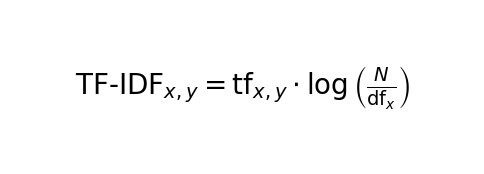

In [39]:
formula = r"$\mathrm{TF\text{-}IDF}_{x,y} = \mathrm{tf}_{x,y} \cdot \log\left(\frac{N}{\mathrm{df}_x}\right)$"

fig = plt.figure(figsize=(6, 2))
plt.text(0.5, 0.5, formula, fontsize=20, ha='center', va='center')
plt.axis('off')

# save
plt.savefig("../plots/tfidf_formula.pdf", dpi=300, bbox_inches='tight', transparent=True)
plt.show()

### 1.2 Data preparations

In [19]:
# inputs
adata = ad.read_h5ad('../data/Enhancers_AnnData.h5ad')

motifs_mapped = '../output/2_2H_Motifs_per_enhancer'
files = glob.glob(f"{motifs_mapped}/*.csv")

In [22]:
# functions
def tfidf_from_tf(TF: pd.DataFrame, N: int | None = None) -> pd.DataFrame:
    """
    Takes: TF scores as a matrix motifs x enhancers
    Returns: TF-IDF with columns sorted alphabetically.
    """
    if N is None:
        N = TF.shape[1] #total number of documents/enhancers used for IDF

    if N < TF.shape[1]:
        raise ValueError(f"N ({N}) is smaller than TF.shape[1] ({TF.shape[1]}).")

    df = (TF > 0).sum(axis=1)
    idf = np.log((1 + N) / (1 + df)) + 1

    return TF.mul(idf, axis=0)

def top_motifs(df, axis=0, nlargest=15,  list_output=False):
    """
    Takes: Dataframe which was an input for scatter plot
    Returns: a list of top motifs closer to x-axis (axis=0) or y-axis (axis=1)
    """
    df_inner = df.copy()
    x_col, y_col = df_inner.columns.to_list()

    if axis > 0:
        df_inner["diff"] = (df_inner[y_col] - df_inner[x_col])
    else:
        df_inner["diff"] = (df_inner[x_col] - df_inner[y_col])
    
    top=df_inner.nlargest(nlargest, "diff")
    top_list = top.index.tolist()
    
    for x in top_list:
        print(x)

    if list_output:
        return(top_list)

def has_target_gene(gene_string, target_genes=target_genes):
    """
    Takes: content of dataframe cell with genes (i.o. need to be applied per row) and a set of traget genes
    Returns: boolean value if the cell content has any of target genes or not
    """
    if pd.isna(gene_string):
        return False
    genes = [g.strip() for g in str(gene_string).split(',')]
    return any(g in target_genes for g in genes)

In [7]:
def diff_motifs_plot(df, plot_filename=None, size_variable=None, nlargest=15, title=None):
    custom_div = mpl.colors.LinearSegmentedColormap.from_list(
    "custom_div",
    ["#6E7688", "#86240A"]
    )
    
    x_col, y_col = df.columns.to_list()
    labels = {x_col: 'Specific enhancers',
             y_col: 'Non-specific enhancers'}
    
    fig, ax = plt.subplots(figsize=(4,4), dpi=200)

    df = df.copy()
    df["abs_diff"] = (df[x_col] - df[y_col]).abs()
    df["diff_x"] = (df[x_col] - df[y_col])
    df["diff_y"] = (df[y_col] - df[x_col])

    sns.scatterplot(
        data=df,
        x=f"{x_col}",
        y=f"{y_col}",
        hue="abs_diff",
        palette=custom_div,
        ax=ax,
        s=20,
        linewidth=0,
        edgecolor=None,
        legend=False,
        size=size_variable
    )

    #top motifs labels 
    texts = []
    top_x = df.nlargest(nlargest, 'diff_x')
    for i, row in top_x.iterrows():
        texts.append(ax.text(row[x_col], row[y_col], f'{str(i)}', fontsize=6, color="black", ha="center", va="center"))

    top_y = df.nlargest(nlargest, 'diff_y')
    for i, row in top_y.iterrows():
        texts.append(ax.text(row[x_col], row[y_col], f'{str(i)}', fontsize=6, color="black", ha="center", va="center"))

    #setting axes scales
    all_vals = pd.concat([df[x_col], df[y_col]])
    vmin, vmax = all_vals.min(), all_vals.max()
    pad = 0.05 * (vmax - vmin if vmax > vmin else 1.0)
    lo, hi = vmin - pad, vmax + pad
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect("equal", adjustable="box")

    # 45-degree line
    ax.plot([lo, hi], [lo, hi], ls="--", lw=1, color="black")

    # labels & aesthetics
    ax.set_xlabel(f'{labels[x_col]}')
    ax.set_ylabel(f'{labels[y_col]}')
    if title:
        ax.set_title(str(title))
    else:
        ax.set_title("TF-IDF score difference")
    sns.despine() #start axis slightly before 0 tick

    # plot labels to motifs
    adjust_text(texts, ax=ax, expand=(1.3, 3), 
                arrowprops=dict(arrowstyle="->", color="gray", lw=0.5))

    plt.tight_layout()
    
    # Optional: save 
    if plot_filename:
        os.makedirs('../plots', exist_ok=True)
        plt.savefig(f"../plots/{plot_filename}.pdf", bbox_inches="tight", transparent=True)
    plt.show()

### 1.3. Calculating TF-IDF score (needs to be run once)

In [42]:
TF_total = []   # Series: index = motif, values = freq, name = enhancer
occ_total = []

# calculating each motif TF score (from TF-=IDF formula) and number of occurences
for file in files:
    df = pd.read_csv(file, sep=';')
    if df.empty:
        continue

    assert df['enh_name'].nunique() == 1
    
    enh_name = df['enh_name'].iloc[0] 
    enh_length = df['enh_length'].iloc[0]

    #total TF score
    total_terms = len(df)
    term_counts = df.groupby('motif_name').size()
    TF = term_counts / total_terms
    TF.name = enh_name
    TF_total.append(TF)

    # Occurencies
    occ_s = df.groupby('motif_name').size()
    occ_s.name = enh_name
    occ_total.append(occ_s)
    

# Matrices
TF_total_mat = pd.DataFrame(TF_total).fillna(0.0).T   # index = motif, columns = enhancers
occ_mat  = pd.DataFrame(occ_total).fillna(0.0).T 

In [43]:
#preparing adata object
adata_TF_IDF = ad.AnnData(
    X=TF_total_mat.to_numpy(), # TF values (they just mean a weight of a motif compared to the total number of motifs of the enhancer)
    obs=pd.DataFrame(index=TF_total_mat.index),     # motifs
    var=pd.DataFrame(index=TF_total_mat.columns),   # enhancers
)
adata_TF_IDF = adata_TF_IDF[:, adata_TF_IDF.var_names.sort_values()].copy() 

# adding var values from the main dataframe
adata_TF_IDF.var["category"] = adata.var.loc[adata_TF_IDF.var_names, "category"]
adata_TF_IDF.var['gene'] = adata.var['gene']
adata_TF_IDF.var['enh_length'] = adata.var['enh_length']

In [44]:
X = adata_TF_IDF.X 

TF_IDF_full = np.zeros_like(X, dtype=float)

# calculating TF-IDF within each category of enhancers (it takes matrix of TF scores and does 
#the rest calculations per each group of enhancer to get TF-IDF)
for cat in adata_TF_IDF.var['category'].unique():
    
    cat_mask = (adata_TF_IDF.var['category'] == cat).to_numpy()
    
    # subset motif × enhancers_of_cat
    X_cat = X[:, cat_mask]
    N = X_cat.shape[1]
    
    if N == 0:
        continue

    tf = X_cat
    df = np.sum(tf > 0, axis=1)

    # IDF
    idf = np.log((N + 1) / (df + 1)) + 1
    
    #TF-IDF
    tfidf = tf * idf[:, None]

    TF_IDF_full[:, cat_mask] = tfidf

adata_TF_IDF.layers['TF_IDF_per_category'] = TF_IDF_full

# layers
adata_TF_IDF.layers['TF_IDF_total'] = tfidf_from_tf(adata_TF_IDF.to_df()) #additional matrix of TF-IDF scores without division by category (so N=total N of enhancers)
adata_TF_IDF.layers['Occurences'] = occ_mat

In [45]:
# calculating mean TF-IDF per motif in each category
for cat in ["conservative", "primate_specific", "other", "human_unique"]:
    mask = (adata_TF_IDF.var["category"] == cat).to_numpy()
    Xsub = adata_TF_IDF[:, mask].layers["TF_IDF_per_category"]
    adata_TF_IDF.obs[cat] = np.asarray(Xsub.mean(axis=1)).ravel()

# NOTE: human_unique category will be too biased due to extremely low number of enhancers
# it's better to not use its TF-IDF in further analysis

In [ ]:
# adding motifs metadata to adata.obs
records = []
with open('../data/5_HOCOMOCO_annotation.jsonl') as f:
    for line in f:
        entry = json.loads(line.strip())
        ml = entry.get('masterlist_info', {})
        records.append({
            'motif_name':         entry.get('name'),
            'tf_name':            entry.get('tf'),
            'tfclass_id':         ml.get('tfclass_id'),
            'tfclass_superclass': ml.get('tfclass_superclass'),
            'tfclass_class':      ml.get('tfclass_class'),
            'tfclass_family':     ml.get('tfclass_family'),
            'tfclass_subfamily':  ml.get('tfclass_subfamily'),
            'collection':         entry.get('collection'),
            'quality':            entry.get('quality'),
        })

df_hocomoco = pd.DataFrame(records)
df_hocomoco.head(3)

,motif_name,tf_name,tfclass_id,tfclass_superclass,tfclass_class,tfclass_family,tfclass_subfamily,collection,quality
0,LEUTX.H14CORE.0.PSGB.A,LEUTX,3.1.3.13.1,Helix-turn-helix domains,Homeo domain factors,Paired-related HD,LEUTX,H14CORE,A
1,FXL19.H14CORE.0.PSGIB.A,FXL19,2.6.1.0.256,Zinc-coordinating DNA-binding domains,CXXC zinc finger factors,CpG-binding,None,H14CORE,A
2,ZFAT.H14CORE.0.PSGI.A,ZFAT,2.3.4.21.2,Zinc-coordinating DNA-binding domains,C2H2 zinc finger factors,Multiple dispersed zinc fingers,HINFP-like,H14CORE,A
3,ZSCA2.H14CORE.0.PG.A,ZSCA2,2.3.3.58.6,Zinc-coordinating DNA-binding domains,C2H2 zinc finger factors,More than 3 adjacent zinc fingers,ZNF180-like,H14CORE,A
4,ZN395.H14CORE.0.PSGI.A,ZN395,2.3.2.255.2,Zinc-coordinating DNA-binding domains,C2H2 zinc finger factors,Other with up to three adjacent zinc fingers,CR1-CR2,H14CORE,A
...,...,...,...,...,...,...,...,...,...
1590,ZSC29.H14CORE.1.M.C,ZSC29,2.3.3.19.4,Zinc-coordinating DNA-binding domains,C2H2 zinc finger factors,More than 3 adjacent zinc fingers,ZNF500-like,H14CORE,C
1591,ZSC31.H14CORE.0.P.C,ZSC31,2.3.3.10.7,Zinc-coordinating DNA-binding domains,C2H2 zinc finger factors,More than 3 adjacent zinc fingers,ZNF24-like,H14CORE,C
1592,ZSC31.H14CORE.1.SM.B,ZSC31,2.3.3.10.7,Zinc-coordinating DNA-binding domains,C2H2 zinc finger factors,More than 3 adjacent zinc fingers,ZNF24-like,H14CORE,B
1593,ZSCA1.H14CORE.0.SM.B,ZSCA1,2.3.2.3.1,Zinc-coordinating DNA-binding domains,C2H2 zinc finger factors,Other with up to three adjacent zinc fingers,SCAN,H14CORE,B


In [47]:
df_hocomoco_dedup = df_hocomoco.drop_duplicates(subset='tf_name') # duplicates have the same metadata but different motif_name since there are several consensus sequences
df_hocomoco_dedup.set_index('tf_name', inplace=True)

In [49]:
#adding motif info to adata.obs
adata_TF_IDF.obs = adata_TF_IDF.obs.merge(
    df_hocomoco_dedup[['tfclass_family', 'tfclass_class', 'tfclass_superclass']],
    left_index=True,
    right_index=True,
    how='left'
)

In [50]:
adata_TF_IDF

AnnData object with n_obs × n_vars = 231 × 11748
    obs: 'conservative', 'primate_specific', 'other', 'human_unique', 'tfclass_family', 'tfclass_class', 'tfclass_superclass'
    var: 'category', 'gene', 'enh_length'
    layers: 'TF_IDF_per_category', 'TF_IDF_total', 'Occurences'

In [51]:
#saving the adata
filename = '../data/Enhancers_AnnData_TF_IDF.h5ad'
adata_TF_IDF.write_h5ad(filename)

### 1.4. Scatter plots category vs category

In [9]:
adata_TF_IDF = ad.read_h5ad('../data/Enhancers_AnnData_TF_IDF.h5ad')

In [10]:
TF_IDF_input =  adata_TF_IDF.obs.loc[:, ['other', 'primate_specific']].copy()

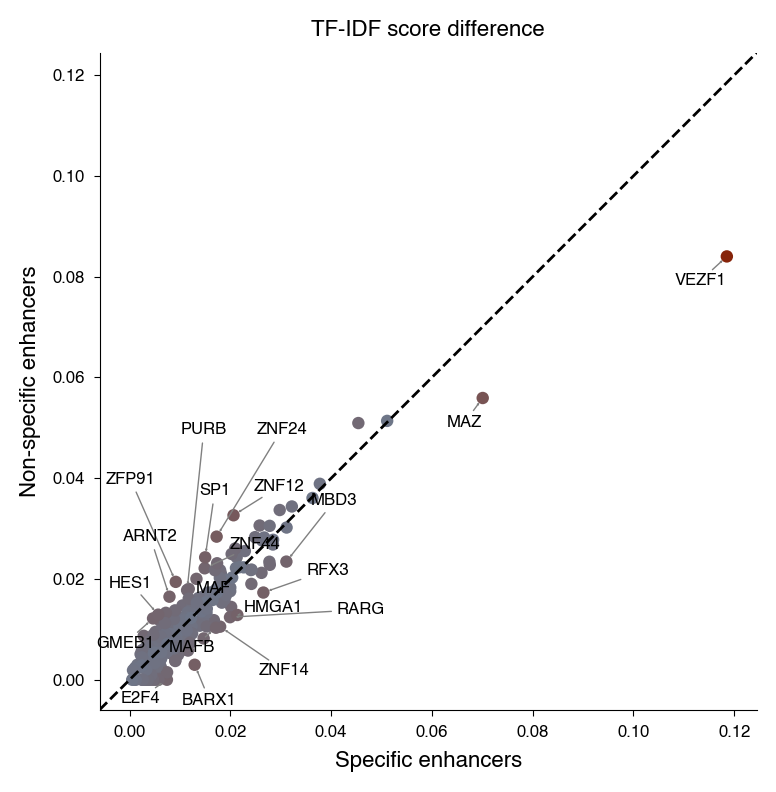

In [12]:
diff_motifs_plot(TF_IDF_input, nlargest=10)

In [16]:
top_motifs(TF_IDF_input, axis=0, nlargest=10)

VEZF1
MAZ
BARX1
RFX3
HMGA1
MBD3
RARG
ZNF14
E2F4
MAFB


## 2 - TF-IDF calculation for genes possesing primate-specific enhancers

### 2.1. Getting adata subset

We take the subset of genes which have at least 1 primate_specific enhancer. Then we fish out all enhancers related to that genes.

In [17]:
adata_TF_IDF = ad.read_h5ad('../data/Enhancers_AnnData_TF_IDF.h5ad')

In [ ]:
#  get all genes linked to primate-specific enhancers
gene_list_PS = adata.var.loc[
    adata.var['category'] == 'primate_specific', 'gene'
].dropna().tolist()

target_genes = set()
for genes in gene_list_PS:
    for g in str(genes).split(','):
        g = g.strip()
        if g:
            target_genes.add(g)

Number of genes possesing at least 1 primate-specific enhancer: 102


In [23]:
# keep recordings of enhancers linked to at least one target gene
enh_mask = adata_TF_IDF.var['gene'].apply(has_target_gene)
adata_sub = adata_TF_IDF[:, enh_mask].copy()
adata_sub

AnnData object with n_obs × n_vars = 231 × 901
    obs: 'conservative', 'primate_specific', 'other', 'human_unique', 'tfclass_family', 'tfclass_class', 'tfclass_superclass'
    var: 'category', 'gene', 'enh_length'
    layers: 'Occurences', 'TF_IDF_per_category', 'TF_IDF_total'

In [24]:
adata_sub.obs.drop(columns=adata_sub.obs[0:3], inplace=True) # deleting previous TF-IDF means

We recalculate TF_IDF layer since IDF measurement depens on total number of enhancers which changed. Now we separate the IDF scoring not by category but by primate-specific vs no primate_specific enhancers.

### 2.2. Recalculation of TF-IDF, plot

In [25]:
X = adata_sub.X 

TF_IDF_full = np.zeros_like(X, dtype=float)

#Total TF-IDF
adata_sub.layers['TF_IDF_total'] = tfidf_from_tf(adata_sub.to_df())

categories = {
    "primate_specific": adata_sub.var['category'] == 'primate_specific',
    "non_primate_specific": adata_sub.var['category'] != 'primate_specific'
}

for cat_name, cat_mask in categories.items():
    Xsub = adata_sub[:, cat_mask].layers["TF_IDF_total"]
    adata_sub.obs[cat_name] = np.asarray(Xsub.mean(axis=1)).ravel()

In [26]:
plot_input = adata_sub.obs
plot_input

,primate_specific,non_primate_specific
motif_name,,
E2F3,0.004206,0.004226
KLF10,0.023382,0.027540
KLF12,0.019353,0.018109
MAZ,0.048507,0.065552
RFX1,0.013104,0.018114
...,...,...
ATF7,0.002567,0.002112
ELF1,0.000000,0.003156
GABPA,0.002547,0.000519


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


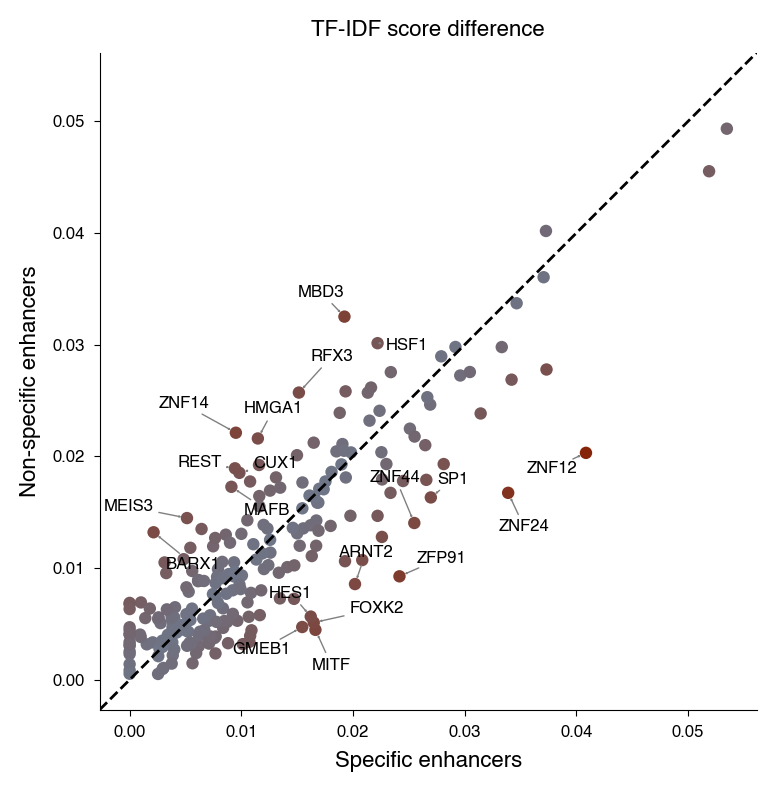

In [28]:
diff_motifs_plot(plot_input[~plot_input.index.isin(['VEZF1', 'MAZ'])], nlargest=10, plot_filename="Scatter_only_genes_related_to_PS_enhancers")

In [29]:
top_motifs(plot_input, nlargest=10)

ZNF12
ZNF24
ZFP91
MITF
ARNT2
ZNF44
FOXK2
GMEB1
SP1
HES1


Mann-Whitney U statistic: 30857.0000
P-value: 1.2804e-01


<Axes: xlabel='primate', ylabel='enh_length'>

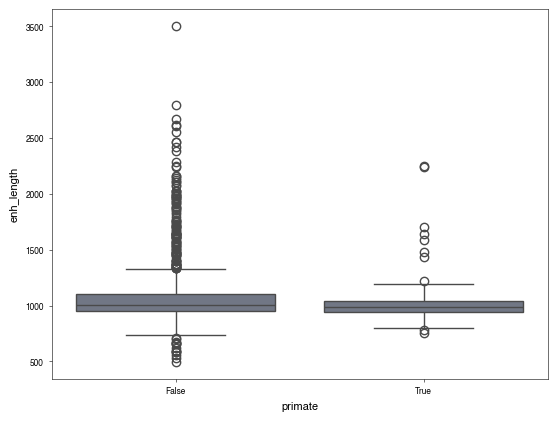

In [31]:
# Additional check: if enhancers from categories have similar enhancer lengh doistribution
df_bp = adata_sub.var.copy()
df_bp['primate'] = df_bp['category'] == 'primate_specific'

# Mann-Whitney U statistic
primate_len = df_bp.loc[df_bp['primate'], 'enh_length']
control_len = df_bp.loc[~df_bp['primate'], 'enh_length']

u_stat, p_val_u = mannwhitneyu(primate_len, control_len, alternative='two-sided')

print(f"Mann-Whitney U statistic: {u_stat:.4f}")
print(f"P-value: {p_val_u:.4e}")

# boxplot
sns.boxplot(data=df_bp, x='primate', y='enh_length', color='#6E7688')

## 3 - TF-IDF calculation per gene

Here we take genes with equal number of enhancers per category (e.g. 4 primate-specific vs 4 non-primate specific) and perform the same steps: 
recalculation of TF-IDF for enhancers of the gene, scatterplot

### 3.1. AFDN (primate-specific enhancers)

In [33]:
#gene of interest
gene = 'AFDN'

mask = adata_TF_IDF.var['gene'].str.contains(gene, regex=False)
gene_adata = adata_TF_IDF[:, mask]

#Total TF-IDF
gene_adata.layers['TF_IDF_total'] = tfidf_from_tf(gene_adata.to_df())

categories = {
    "primate_specific": gene_adata.var['category'] == 'primate_specific',
    "non_primate_specific": gene_adata.var['category'] != 'primate_specific'
}

for cat_name, cat_mask in categories.items():
    Xsub = gene_adata[:, cat_mask].layers["TF_IDF_total"]
    gene_adata.obs[cat_name] = np.asarray(Xsub.mean(axis=1)).ravel()

plot_input = gene_adata.obs[['primate_specific', 'non_primate_specific']]
plot_input.head(3)

/tmp/ipykernel_1758934/2693740749.py:8: ImplicitModificationWarning: Setting element `.layers['TF_IDF_total']` of view, initializing view as actual.
  gene_adata.layers['TF_IDF_total'] = tfidf_from_tf(gene_adata.to_df())


,primate_specific,non_primate_specific
motif_name,,
E2F3,0.000000,0.019563
KLF10,0.016395,0.046636
KLF12,0.017389,0.000000


26 [ 0.71022155 -0.12079501]
27 [-0.15787723  0.33517038]
28 [0.73756293 0.96858709]
21 [-0.21500162  0.10171856]
22 [-0.75006955 -0.91000087]
23 [ 0.94383704 -0.89134625]
17 [-0.87578689 -0.09897853]
18 [-0.18345291 -0.78794319]
15 [0.37243516 0.59905064]
16 [0.41435972 0.40145085]
10 [-0.37576382 -0.95164687]
11 [ 0.31705869 -0.92351376]
12 [0.73102271 0.1512199 ]
13 [0.74903528 0.20858164]


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


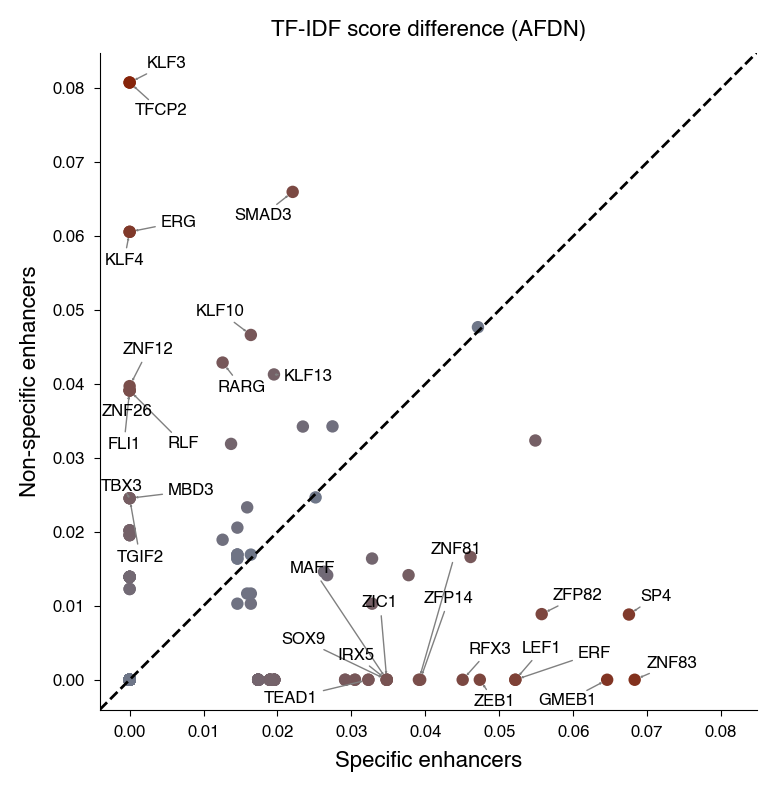

In [34]:
diff_motifs_plot(plot_input[~plot_input.index.isin(['VEZF1', 'MAZ'])], plot_filename='AFDN_TF_IDF_score', title='TF-IDF score difference (AFDN)')

In [35]:
top_motifs(plot_input, axis=0)

ZNF83
GMEB1
SP4
ERF
LEF1
ZEB1
ZFP82
RFX3
ZFP14
ZNF81
ZIC1
SOX9
MAFF
IRX5
TEAD1


### 3.2. SGCZ (human unique enhancer)

In [39]:
#gene of interest
gene = 'SGCZ'

mask = adata_TF_IDF.var['gene'].str.contains(gene, regex=False)
gene_adata = adata_TF_IDF[:, mask]

#Total TF-IDF
gene_adata.layers['TF_IDF_total'] = tfidf_from_tf(gene_adata.to_df())

categories = {
    "human_specific": gene_adata.var['category'] == 'human_unique',
    "non_human_specific": gene_adata.var['category'] != 'human_unique'
}

for cat_name, cat_mask in categories.items():
    Xsub = gene_adata[:, cat_mask].layers["TF_IDF_total"]
    gene_adata.obs[cat_name] = np.asarray(Xsub.mean(axis=1)).ravel()

plot_input = gene_adata.obs[['human_specific', 'non_human_specific']]
plot_input.head(3)

/tmp/ipykernel_1758934/4089436789.py:8: ImplicitModificationWarning: Setting element `.layers['TF_IDF_total']` of view, initializing view as actual.
  gene_adata.layers['TF_IDF_total'] = tfidf_from_tf(gene_adata.to_df())


,human_specific,non_human_specific
motif_name,,
E2F3,0.000000,0.0
KLF10,0.000000,0.0
KLF12,0.061107,0.0


20 [-0.58440213 -0.71864503]
21 [-0.23749511  0.57857456]
22 [0.86462452 0.91680482]
23 [0.3912875  0.59888239]
24 [-0.47080914 -0.6959667 ]
25 [-0.91160116  0.40285754]
26 [-0.58917595  0.86038372]
27 [0.61736959 0.80746843]
28 [-0.83441803  0.92868642]
29 [0.65248646 0.32341824]
17 [0.08446999 0.90555563]
18 [ 0.10540648 -0.25789634]
19 [0.14036328 0.79763622]
3 [0.6375422  0.89054436]
4 [ 0.92341772 -0.35780636]
5 [-0.00988974 -0.04187169]
6 [-0.06368889  0.44595414]
7 [0.93597727 0.12842794]
8 [0.66427282 0.30802007]
9 [0.90783579 0.61925281]
10 [-0.42588096  0.06241001]
11 [0.91129662 0.59135051]
12 [-0.35780589 -0.89749535]
13 [-0.94664015  0.23690934]
14 [-0.50485089  0.4516051 ]


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


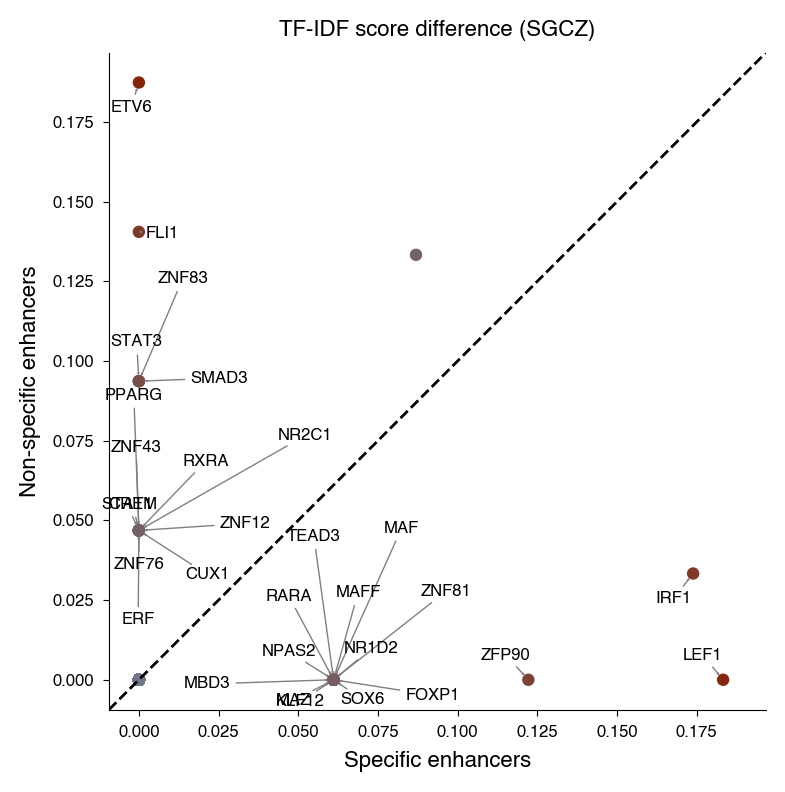

In [40]:
diff_motifs_plot(plot_input, nlargest=15,  plot_filename='SGCZ_TF_IDF_score', title='TF-IDF score difference (SGCZ)')

In [41]:
top_motifs(plot_input, axis=0)

LEF1
IRF1
ZFP90
KLF12
MAZ
RARA
NPAS2
NR1D2
MAFF
MBD3
TEAD3
MAF
FOXP1
ZNF81
SOX6
